In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
url_imoveis = "https://raw.githubusercontent.com/JulianaMoretto/Postech-data-analytics/refs/heads/main/Machine-Learning/Valorizacao_Ambiental.csv"
imoveis = pd.read_csv(url_imoveis,sep=";")
imoveis.head()

,Ordem,Valor,Area,IA,Andar,Suites,Vista,DistBM,Semruido,AV100m
0,1,160000,168,1,5,1,1,294,1,0
1,2,67000,129,1,6,0,0,1505,1,0
2,3,190000,218,1,8,1,0,251,0,1
3,4,110000,180,12,4,1,0,245,0,0
4,5,70000,120,15,3,1,0,956,1,0


In [3]:
imoveis.head()

,Ordem,Valor,Area,IA,Andar,Suites,Vista,DistBM,Semruido,AV100m
0,1,160000,168,1,5,1,1,294,1,0
1,2,67000,129,1,6,0,0,1505,1,0
2,3,190000,218,1,8,1,0,251,0,1
3,4,110000,180,12,4,1,0,245,0,0
4,5,70000,120,15,3,1,0,956,1,0


In [4]:
imoveis.describe()

,Ordem,Valor,Area,IA,Andar,Suites,Vista,DistBM,Semruido,AV100m
count,172.000000,172.000000,172.000000,172.000000,172.000000,172.000000,172.000000,172.000000,172.000000,172.000000
mean,86.500000,173541.953488,163.203488,5.645349,4.296512,1.395349,0.139535,505.889535,0.581395,0.348837
std,49.796252,99827.094479,65.915145,5.570057,2.239828,1.126803,0.347516,395.054522,0.494771,0.477994
min,1.000000,40000.000000,69.000000,1.000000,1.000000,0.000000,0.000000,73.000000,0.000000,0.000000
25%,43.750000,104750.000000,117.000000,1.000000,2.750000,1.000000,0.000000,214.750000,0.000000,0.000000
50%,86.500000,149000.000000,145.000000,2.500000,4.000000,1.000000,0.000000,402.500000,1.000000,0.000000
75%,129.250000,209250.000000,182.000000,11.000000,6.000000,2.000000,0.000000,638.000000,1.000000,1.000000
max,172.000000,579840.000000,393.000000,19.000000,12.000000,6.000000,1.000000,1859.000000,1.000000,1.000000


In [5]:
imoveis.isnull().sum()

,0
Ordem,0
Valor,0
Area,0
IA,0
Andar,0
Suites,0
Vista,0
DistBM,0
Semruido,0
AV100m,0


In [6]:
imoveis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Ordem     172 non-null    int64
 1   Valor     172 non-null    int64
 2   Area      172 non-null    int64
 3   IA        172 non-null    int64
 4   Andar     172 non-null    int64
 5   Suites    172 non-null    int64
 6   Vista     172 non-null    int64
 7   DistBM    172 non-null    int64
 8   Semruido  172 non-null    int64
 9   AV100m    172 non-null    int64
dtypes: int64(10)
memory usage: 13.6 KB


Identificando a variável target

(array([85., 55., 21.,  8.,  3.]),
 array([ 40000., 147968., 255936., 363904., 471872., 579840.]),
 <BarContainer object of 5 artists>)

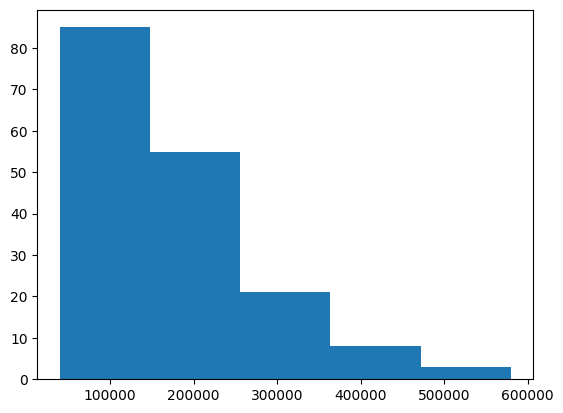

In [7]:
plt.hist(imoveis["Valor"],bins=5)

Transformar o formato da variável principal para raiz quadrada.

Visualizar dados no formato da raiz quadrada pode ser uma boa opção! A transformação pode ajudar a mostrar a relação proporcional entre diferentes quantidades de uma maneira mais clara e intuitiva.

In [8]:
imoveis["raiz_valor"] = np.sqrt(imoveis["Valor"])
imoveis.head()

,Ordem,Valor,Area,IA,Andar,Suites,Vista,DistBM,Semruido,AV100m,raiz_valor
0,1,160000,168,1,5,1,1,294,1,0,400.000000
1,2,67000,129,1,6,0,0,1505,1,0,258.843582
2,3,190000,218,1,8,1,0,251,0,1,435.889894
3,4,110000,180,12,4,1,0,245,0,0,331.662479
4,5,70000,120,15,3,1,0,956,1,0,264.575131


(array([39., 73., 40., 14.,  6.]),
 array([200.        , 312.29445164, 424.58890328, 536.88335492,
        649.17780656, 761.47225819]),
 <BarContainer object of 5 artists>)

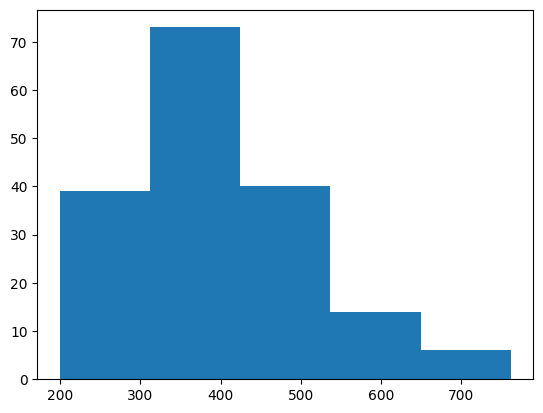

In [9]:
plt.hist(imoveis["raiz_valor"],bins=5)

Analisando as variáveis quantitativas

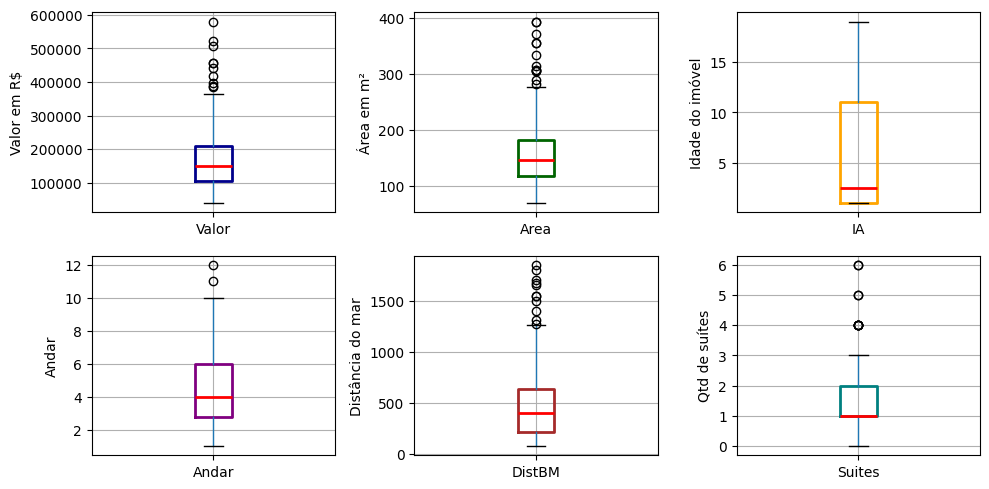

In [10]:
plt.figure(figsize=(10,5))

plt.subplot(2,3,1) #numero de linhas, numero de colunas, posicao
fig = imoveis.boxplot(column="Valor",boxprops=dict(color='darkblue', linewidth=2),medianprops=dict(color='red', linewidth=2))
fig.set_title("")
fig.set_ylabel("Valor em R$")

plt.subplot(2,3,2)
fig = imoveis.boxplot(column="Area",boxprops=dict(color='darkgreen', linewidth=2),medianprops=dict(color='red', linewidth=2))
fig.set_title("")
fig.set_ylabel("Área em m²")

plt.subplot(2,3,3)
fig = imoveis.boxplot(column="IA",boxprops=dict(color='orange', linewidth=2),medianprops=dict(color='red', linewidth=2))
fig.set_title("")
fig.set_ylabel("Idade do imóvel")

plt.subplot(2,3,4)
fig = imoveis.boxplot(column="Andar",boxprops=dict(color='purple', linewidth=2),medianprops=dict(color='red', linewidth=2))
fig.set_title("")
fig.set_ylabel("Andar")

plt.subplot(2,3,5)
fig = imoveis.boxplot(column="DistBM",boxprops=dict(color='brown', linewidth=2),medianprops=dict(color='red', linewidth=2))
fig.set_title("")
fig.set_ylabel("Distância do mar")

plt.subplot(2,3,6)
fig = imoveis.boxplot(column="Suites",boxprops=dict(color='teal', linewidth=2),medianprops=dict(color='red', linewidth=2))
fig.set_title("")
fig.set_ylabel("Qtd de suítes")

plt.tight_layout()
plt.show()

###Analisando correlações

Correlação de Pearson - quando as variáveis são núméricas quantitativas

ρ = 0,9 a 1 (positivo ou negativo): correlação muito forte;
ρ = 0,7 a 0,9 (positivo ou negativo): correlação forte;
ρ = 0,5 a 0,7 (positivo ou negativo): correlação moderada;
ρ = 0,3 a 0,5 (positivo ou negativo): correlação fraca;
ρ = 0 a 0,3 (positivo ou negativo): não possui correlação.

<Axes: >

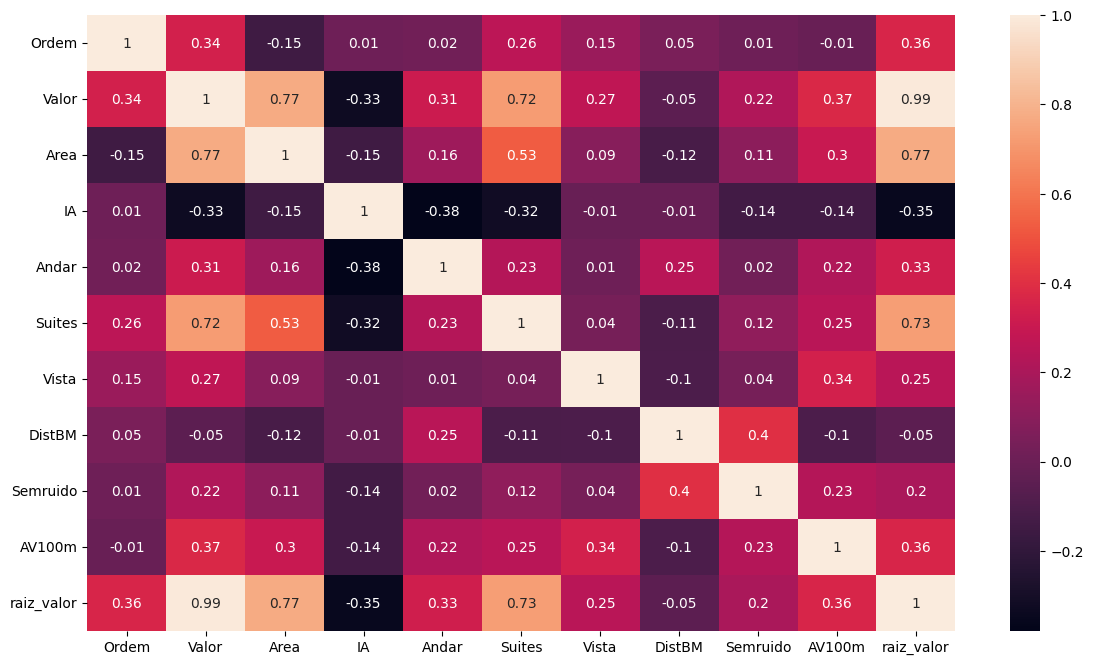

In [11]:
matrix = imoveis.corr().round(2)
fig,ax = plt.subplots(figsize=(14,8))
sns.heatmap(matrix,annot=True,ax=ax)

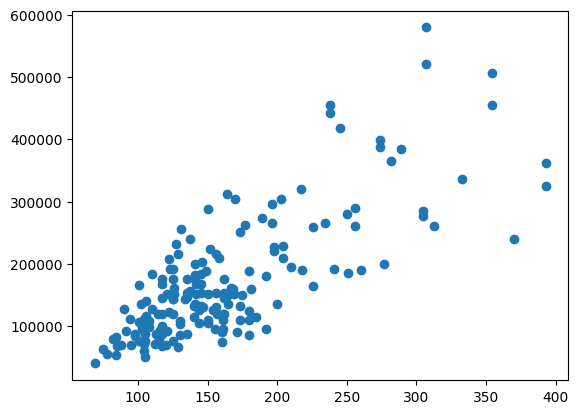

In [12]:
plt.scatter("Area","Valor",data=imoveis)

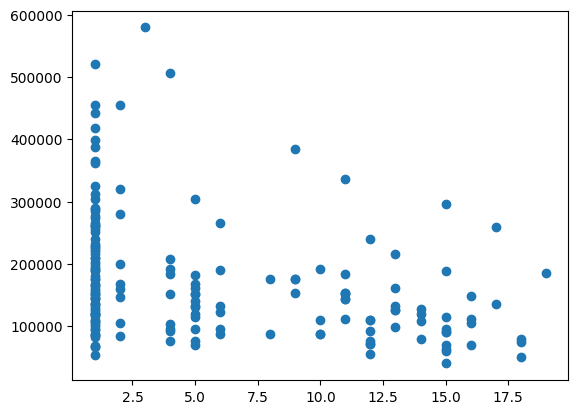

In [13]:
plt.scatter("IA","Valor",data=imoveis)

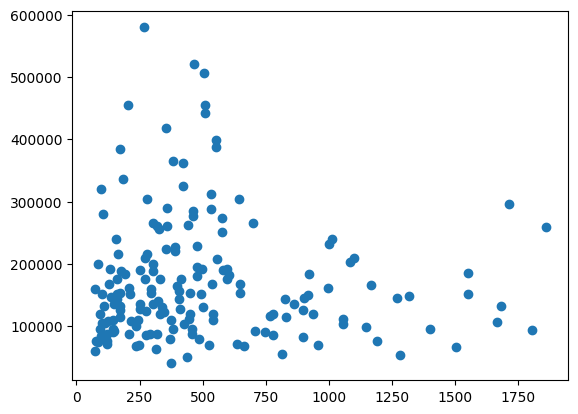

In [14]:
plt.scatter("DistBM","Valor",data=imoveis)

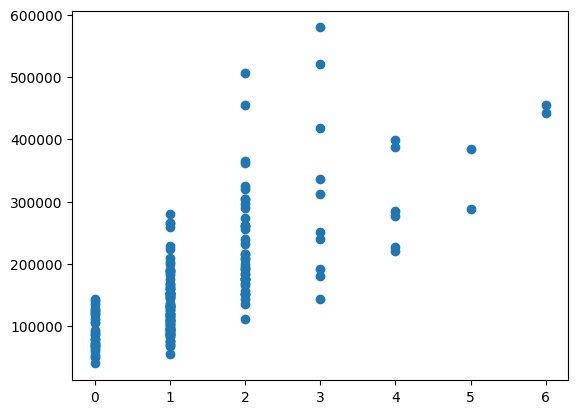

In [15]:
plt.scatter("Suites","Valor",data=imoveis)

###Analisando variáveis qualitativas

<Axes: xlabel='Vista', ylabel='Valor'>

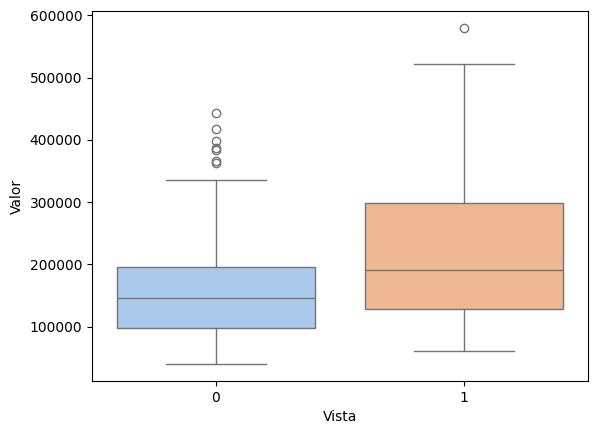

In [16]:
sns.boxplot(x="Vista",y="Valor",hue="Vista",data=imoveis,palette="pastel",legend=False)

<Axes: xlabel='Semruido', ylabel='Valor'>

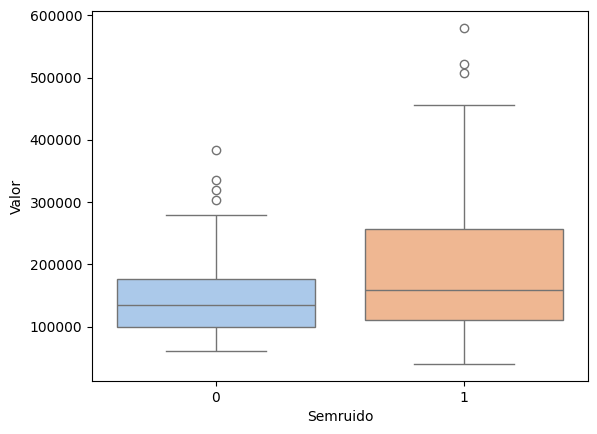

In [17]:
sns.boxplot(x="Semruido",y="Valor",hue="Semruido",data=imoveis,palette="pastel",legend=False)

<Axes: xlabel='AV100m', ylabel='Valor'>

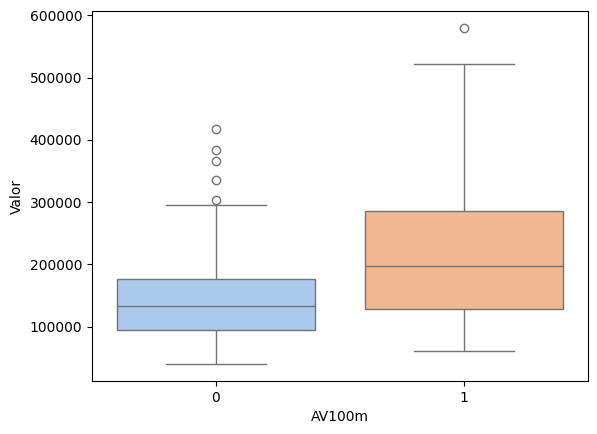

In [18]:
sns.boxplot(x="AV100m",y="Valor",hue="AV100m",data=imoveis,palette="pastel",legend=False)

Text(0.5, 1.0, 'Distribuição do valor — Sem área verde até 100m')

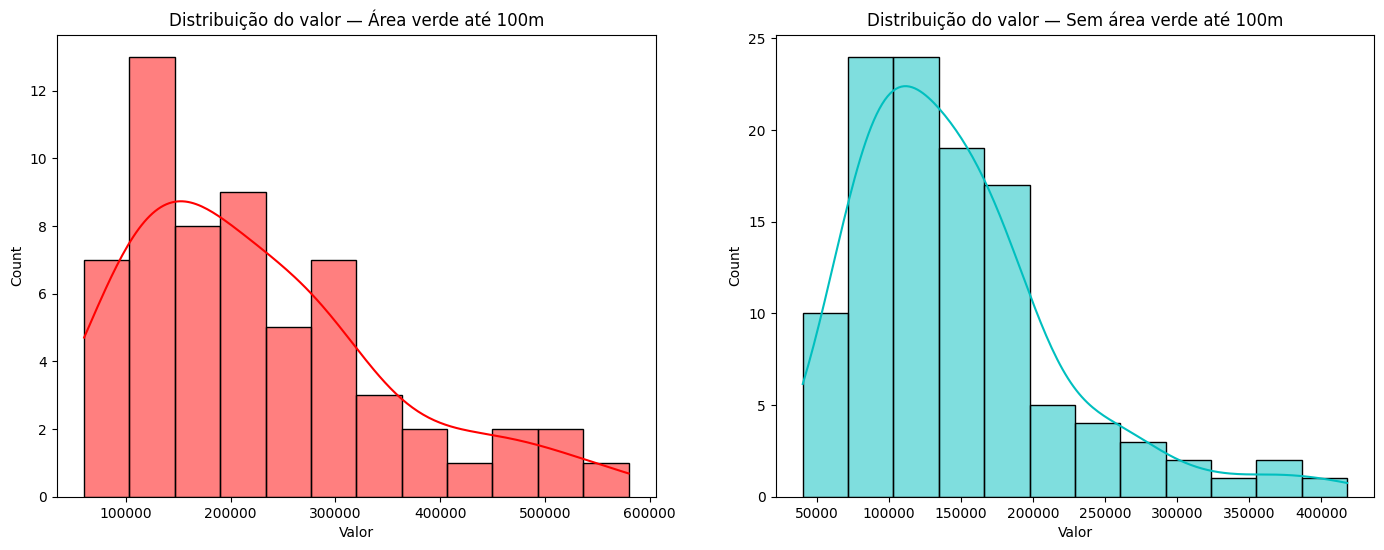

In [19]:
fig = plt.figure(figsize=(17,6))

ax = fig.add_subplot(121) #1 linha, 2 colunas, posicao 1
sns.histplot(imoveis.loc[imoveis.AV100m == 1, "Valor"],
            bins=12, kde=True, stat="count", color="r", ax=ax)
ax.set_title("Distribuição do valor — Área verde até 100m")

ax = fig.add_subplot(122)
sns.histplot(imoveis.loc[imoveis.AV100m == 0, "Valor"],
            bins=12, kde=True, stat="count", color="c", ax=ax)
ax.set_title("Distribuição do valor — Sem área verde até 100m")

Text(0.5, 1.0, 'Distribuição do valor — Sem área verde até 100m')

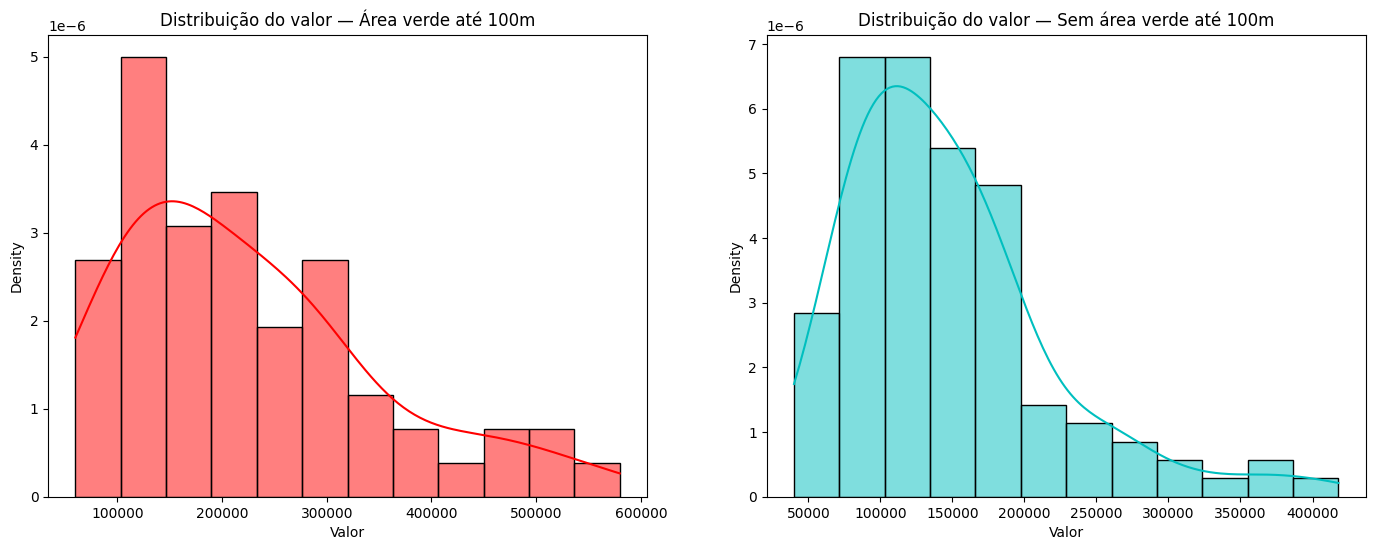

In [20]:
fig = plt.figure(figsize=(17,6))

ax = fig.add_subplot(121)
sns.histplot(imoveis.loc[imoveis.AV100m == 1, "Valor"],
            bins=12, kde=True, stat="density", color="r", ax=ax)
ax.set_title("Distribuição do valor — Área verde até 100m")

ax = fig.add_subplot(122)
sns.histplot(imoveis.loc[imoveis.AV100m == 0, "Valor"],
            bins=12, kde=True, stat="density", color="c", ax=ax)
ax.set_title("Distribuição do valor — Sem área verde até 100m")

##Realizando testes estatísticos

Será que o valor é afetado por imóveis sem ruídos? Vamos comprovar com o teste estatístico Qui-Quadrado.

O teste Qui-Quadrado é uma técnica estatística utilizada para avaliar a associação entre duas variáveis categóricas em uma tabela de contingência.

Ele pode ser utilizado para testar a hipótese de que não há relação entre as duas variáveis ou para identificar se uma variável afeta a outra.

Nesse caso, estamos buscando descobrir a associação entre duas variáveis: faixa valor (qualitativa ordinal) vs Semruido(qualitativa ordinal).

Para transformar a coluna de valor (quantitativa), vamos criar uma faixa de valores utilizando os quartis.

In [21]:
# Criar uma variável outlier_renda no Data Frame, sendo 0 = não outlier, 1= outlier e 2 = ponto extremo
#minimo = min.(df['total'])
Q1 =  np.percentile(imoveis['Valor'], 25)
Q2 =  np.percentile(imoveis['Valor'], 50)
Q3 =  np.percentile(imoveis['Valor'], 75)
maximo = max(imoveis['Valor'])
print(Q1, Q2, Q3, maximo)

104750.0 149000.0 209250.0 579840


In [22]:
imoveis.loc[(imoveis.Valor >= 0) & (imoveis.Valor <= Q1), 'fx_total']=1.0
imoveis.loc[(imoveis.Valor > Q1) & (imoveis.Valor <= Q2), 'fx_total']=2.0
imoveis.loc[(imoveis.Valor>  Q2)  & (imoveis.Valor <=Q3), 'fx_total']=3.0
imoveis.loc[(imoveis.Valor >  Q3) & (imoveis.Valor <= maximo), 'fx_total']=4.0

<Axes: xlabel='fx_total', ylabel='Valor'>

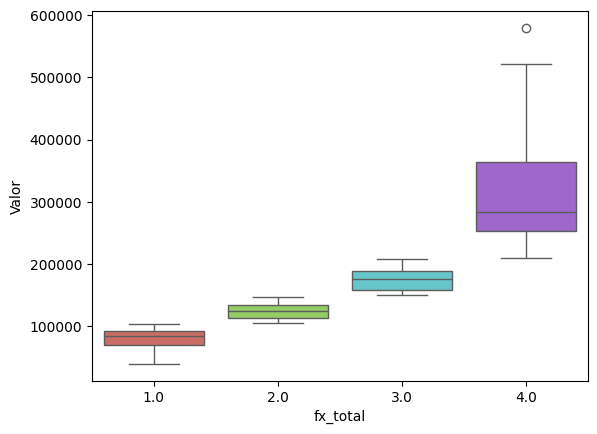

In [23]:
# Boxplot da variável Valor versus a variável categoria de valor
sns.boxplot(x='fx_total', y='Valor', data=imoveis, palette='hls')

In [24]:
imoveis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Ordem       172 non-null    int64  
 1   Valor       172 non-null    int64  
 2   Area        172 non-null    int64  
 3   IA          172 non-null    int64  
 4   Andar       172 non-null    int64  
 5   Suites      172 non-null    int64  
 6   Vista       172 non-null    int64  
 7   DistBM      172 non-null    int64  
 8   Semruido    172 non-null    int64  
 9   AV100m      172 non-null    int64  
 10  raiz_valor  172 non-null    float64
 11  fx_total    172 non-null    float64
dtypes: float64(2), int64(10)
memory usage: 16.3 KB


In [25]:
# crosstab tabela cruzada entre duas variáveis qualitativas

pd.crosstab(imoveis.fx_total,imoveis.Semruido, margins=True)

Semruido,0,1,All
fx_total,,,
1.0,20,23,43
2.0,22,21,43
3.0,21,22,43
4.0,9,34,43
All,72,100,172


Isso já sugere associação (caros → mais “sem ruído”), mas ainda falta o teste.

In [26]:
# Uma variável sem_ruído
(imoveis.Semruido.value_counts() / imoveis.shape[0]) * 100

,count
Semruido,
1,58.139535
0,41.860465


In [27]:
table = pd.crosstab(imoveis.fx_total,imoveis.Semruido)

In [28]:
print(table)

Semruido   0   1
fx_total        
1.0       20  23
2.0       22  21
3.0       21  22
4.0        9  34


Utilizando a biblioteca SciPy que é uma biblioteca de computação científica em Python que fornece um conjunto de ferramentas para matemática, ciência e engenharia.

A função chi2_contingency calcula a estatística do qui-quadrado e o valor p para a tabela de contingência fornecida. A estatística do qui-quadrado é uma medida da discrepância entre a distribuição observada e a distribuição esperada sob a hipótese nula de independência das duas variáveis. O valor p é a probabilidade de obter uma estatística do qui-quadrado tão extrema quanto a observada, sob a hipótese nula.

Em geral, um valor de p menor que 0,05 (ou 0,01, dependendo do contexto) é frequentemente considerado como uma evidência forte contra a hipótese nula, e um valor de p maior que 0,10 geralmente é considerado como uma evidência fraca.

In [29]:
from scipy.stats import chi2_contingency
from scipy.stats import chi2

chi2_contingency - usa a matriz de contagem observada, sem linha e coluna de All

stat: estatística do Qui-Quadrado (o “tamanho do desvio” entre observado e esperado)

p: p-valor

dof: graus de liberdade

expected: tabela esperada se não houvesse relação

In [30]:
# dof degree of freedom
# p p-value
stat, p, dof, expected = chi2_contingency(table)
p

np.float64(0.014685713198671485)

como 0.0147 < 0.05, rejeita H₀

existe associação entre fx_total e Semruido

Teste de hipótese:
H0: não há relação entre valor e ruído
H1: há relação entre valor e ruído
α = 0,05 (5%)

In [31]:
print('Graus de liberdade: dof=%d' % dof) #como a tabela é 4x2 então dof fica, dof = (4-1)*(2-1) = 3

print('\n Tabela Esperada:')
print(expected)

# interpret test-statistic
prob = 0.95
critical = chi2.ppf(prob, dof)

print('\n probability=%.3f, critical=%.3f, stat=%.3f' % (prob, critical, stat))

if abs(stat) >= critical:
	print('\n Dependent (reject H0)')
else:
	print('\n Independent (fail to reject H0)')
# interpret p-value
alpha = 1.0 - prob
print('\n significance=%.3f, p=%.3f' % (alpha, p))
if p <= alpha:
	print('\n Dependent (reject H0)')
else:
	print('\n Independent (fail to reject H0)')

Graus de liberdade: dof=3

 Tabela Esperada:
[[18. 25.]
 [18. 25.]
 [18. 25.]
 [18. 25.]]

 probability=0.950, critical=7.815, stat=10.511

 Dependent (reject H0)

 significance=0.050, p=0.015

 Dependent (reject H0)


A matriz 18 25, significa que se não houvesse relação entre cada faixa, teríamos em cada faixa o resultado 18 com ruído e 25 sem. Porém observamos 9 e 34 na faixa 4.

In [32]:
!pip install researchpy
import researchpy

In [33]:
results1 = researchpy.crosstab(imoveis['fx_total'],imoveis['Semruido'], test='chi-square')

In [34]:
results1

(         Semruido          
 Semruido        0    1  All
 fx_total                   
 1.0            20   23   43
 2.0            22   21   43
 3.0            21   22   43
 4.0             9   34   43
 All            72  100  172,
                 Chi-square test  results
 0  Pearson Chi-square ( 3.0) =   10.5111
 1                    p-value =    0.0147
 2                 Cramer's V =    0.2472)

0.247 é associação fraca a moderada (não é enorme, mas existe e é consistente).

In [35]:
results2 = researchpy.crosstab(imoveis['fx_total'],imoveis['Vista'], test='chi-square')

In [36]:
results2

(         Vista         
 Vista        0   1  All
 fx_total               
 1.0         41   2   43
 2.0         36   7   43
 3.0         39   4   43
 4.0         32  11   43
 All        148  24  172,
                 Chi-square test  results
 0  Pearson Chi-square ( 3.0) =    8.9099
 1                    p-value =    0.0305
 2                 Cramer's V =    0.2276)

0.2276 (fraca a moderada)

In [37]:
results3 = researchpy.crosstab(imoveis['fx_total'],imoveis['AV100m'], test='chi-square')

In [38]:
results3

(         AV100m         
 AV100m        0   1  All
 fx_total                
 1.0          36   7   43
 2.0          30  13   43
 3.0          31  12   43
 4.0          15  28   43
 All         112  60  172,
                 Chi-square test  results
 0  Pearson Chi-square ( 3.0) =   25.1857
 1                    p-value =    0.0000
 2                 Cramer's V =    0.3827)

0.3827 (moderada)

In [39]:
# Avaliando a variável Distancia do Imovel do Mar
Q1 =  np.percentile(imoveis['DistBM'], 25)
Q2 =  np.percentile(imoveis['DistBM'], 50)
Q3 =  np.percentile(imoveis['DistBM'], 75)
maximo = max(imoveis['DistBM' ])
print(Q1, Q2, Q3, maximo)

214.75 402.5 638.0 1859


In [40]:
imoveis.loc[(imoveis.DistBM >= 0) & (imoveis.DistBM <= Q1), 'fx_DistBM']=1.0
imoveis.loc[(imoveis.DistBM > Q1) & (imoveis.DistBM <= Q2), 'fx_DistBM']=2.0
imoveis.loc[(imoveis.DistBM>  Q2)  & (imoveis.DistBM <=Q3), 'fx_DistBM']=3.0
imoveis.loc[(imoveis.DistBM >  Q3) & (imoveis.DistBM <= maximo), 'fx_DistBM']=4.0

<Axes: xlabel='fx_DistBM', ylabel='DistBM'>

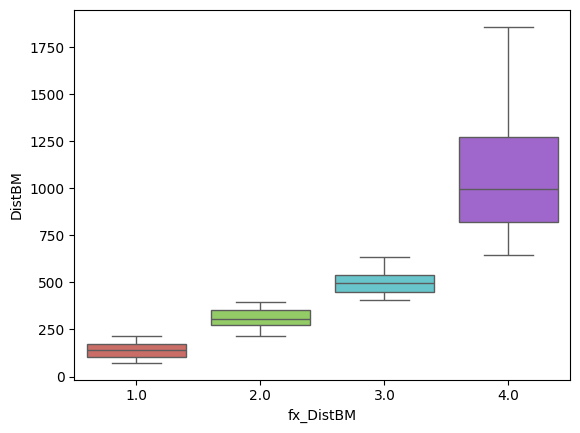

In [41]:
# Boxplot da variável Valor versus a variável categoria de valor
sns.boxplot(x='fx_DistBM', y='DistBM', data=imoveis, palette='hls')

In [42]:
results4 = researchpy.crosstab(imoveis['fx_total'],imoveis['fx_DistBM'], test='chi-square')

In [43]:
results4

(          fx_DistBM                 
 fx_DistBM       1.0 2.0 3.0 4.0  All
 fx_total                            
 1.0              12  10   7  14   43
 2.0              12  11   7  13   43
 3.0              12   9  13   9   43
 4.0               7  13  16   7   43
 All              43  43  43  43  172,
                 Chi-square test  results
 0  Pearson Chi-square ( 9.0) =   11.2558
 1                    p-value =    0.2586
 2                 Cramer's V =    0.1477)

Não há evidência estatística de associação entre faixa de valor e faixa de distância (com esse corte e amostra).

In [44]:
Q1 = np.percentile(imoveis['Area'], 25)
Q2 = np.percentile(imoveis['Area'], 50)
Q3 = np.percentile(imoveis['Area'], 75)
max_area = imoveis['Area'].max()

print(Q1, Q2, Q3, max_area)

117.0 145.0 182.0 393


In [45]:
imoveis.loc[(imoveis.Area <= Q1), 'fx_Area'] = 1
imoveis.loc[(imoveis.Area > Q1) & (imoveis.Area <= Q2), 'fx_Area'] = 2
imoveis.loc[(imoveis.Area > Q2) & (imoveis.Area <= Q3), 'fx_Area'] = 3
imoveis.loc[(imoveis.Area > Q3), 'fx_Area'] = 4

<Axes: xlabel='fx_Area', ylabel='Area'>

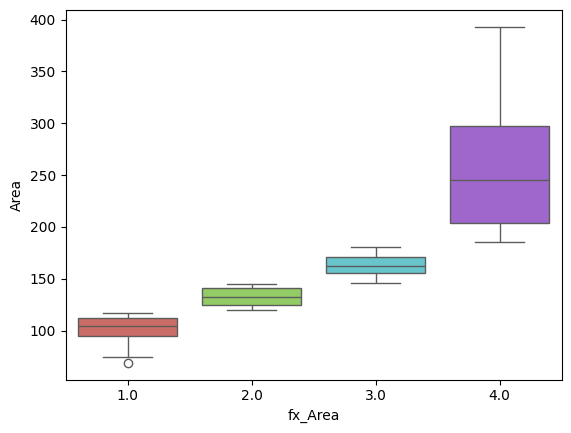

In [46]:
sns.boxplot(x='fx_Area', y='Area', data=imoveis, palette='hls')

In [47]:
results5 = researchpy.crosstab(imoveis['fx_total'],imoveis['fx_Area'], test='chi-square')

In [48]:
results5

(         fx_Area                 
 fx_Area      1.0 2.0 3.0 4.0  All
 fx_total                         
 1.0           29   7   6   1   43
 2.0           12  13  16   2   43
 3.0            4  18  12   9   43
 4.0            0   4   8  31   43
 All           45  42  42  43  172,
                 Chi-square test   results
 0  Pearson Chi-square ( 9.0) =   115.1350
 1                    p-value =     0.0000
 2                 Cramer's V =     0.4724)

Rejeita-se H₀

Existe associação estatisticamente significativa entre: faixa de valor do imóvel e faixa de área construída

In [49]:
results6 = researchpy.crosstab(imoveis['fx_total'],imoveis['IA'], test='chi-square')

In [50]:
results6

(          IA                                                          
 IA         1  2  3  4   5  6  8  9 10 11 12 13 14  15 16 17 18 19  All
 fx_total                                                              
 1.0       12  1  0  4   3  2  1  0  2  0  5  1  1   7  1  0  3  0   43
 2.0       17  2  0  0   5  2  0  0  1  3  2  3  3   1  3  1  0  0   43
 3.0       18  3  0  4   5  1  1  3  1  4  0  1  0   1  0  0  0  1   43
 4.0       30  3  1  1   1  1  0  1  0  1  1  1  0   1  0  1  0  0   43
 All       77  9  1  9  14  6  2  4  4  8  8  6  4  10  4  2  3  1  172,
                  Chi-square test  results
 0  Pearson Chi-square ( 51.0) =   83.5763
 1                     p-value =    0.0027
 2                  Cramer's V =    0.4025)

0.4025 (moderada)

In [51]:
results7 = researchpy.crosstab(imoveis['fx_total'],imoveis['Andar'], test='chi-square')

In [52]:
results7

(         Andar                                           
 Andar        1   2   3   4   5   6  7  8  9 10 11 12  All
 fx_total                                                 
 1.0          9  10   9   2   7   3  2  0  1  0  0  0   43
 2.0          3  12   7   4   6   4  3  1  2  1  0  0   43
 3.0          0   6   9   6   7  10  1  2  1  0  0  1   43
 4.0          0   3   7   8   8   8  1  6  1  0  1  0   43
 All         12  31  32  20  28  25  7  9  5  1  1  1  172,
                  Chi-square test  results
 0  Pearson Chi-square ( 33.0) =   54.7097
 1                     p-value =    0.0102
 2                  Cramer's V =    0.3256)

0.3256 (fraca a moderada)

Interpretação:

Andares mais altos aparecem mais nos imóveis de faixas mais caras (associação existe, mas não é muito forte).

##Conclusão
Fechamento: leitura dos principais resultados

Semruido: associação significativa (p=0.0147), força fraca-moderada (V=0.247)

Vista: significativa (p=0.0305), força fraca-moderada (V=0.228)

AV100m: muito significativa (p≈0), força moderada (V=0.383)

DistBM (em faixas): não significativa (p=0.2586)

Area: Associação moderada a forte com (V=0.4724)

IA e Andar: significativos, força moderada / fraca-moderada

## Regressão Linear

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
lr = LinearRegression()

In [54]:
x = imoveis[["Area","Suites","IA","Semruido","Vista","Andar","AV100m","DistBM"]]
y = imoveis[["Valor"]]

In [55]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=101)

In [56]:
lr.fit(x_train,y_train)

LinearRegression()

In [57]:
y_pred = lr.predict(x_test)

In [74]:
r_sq = lr.score(x_test, y_test)
print(r_sq)

0.7584591969125003


O que isso significa

O modelo explica ~75,8% da variação do Valor em dados que ele nunca viu

Interpretação técnica

O modelo apresenta bom poder explicativo e generaliza bem para dados fora da amostra.

In [75]:
r_sq2 = lr.score(x_train, y_train)
print(r_sq2)

0.8136592063952924


O modelo foi “treinado” nesses dados

É esperado que o ajuste seja melhor

In [76]:
r_sq3 = lr.score(x, y)
print(r_sq3)

0.8060354276078809


Ele usa dados já “vistos”

Sofre overfitting por definição

Serve apenas como referência interna

In [60]:
print('Intercepto:', lr.intercept_)

Intercepto: [-40165.8752773]


In [61]:
coefficients = pd.concat([pd.DataFrame(x.columns),pd.DataFrame(np.transpose(lr.coef_))], axis = 1)
coefficients

,0,0
0,Area,815.218075
1,Suites,34315.785459
2,IA,-1052.417100
3,Semruido,17027.508944
4,Vista,63486.030935
5,Andar,5635.237485
6,AV100m,-5672.535051
7,DistBM,-2.522530


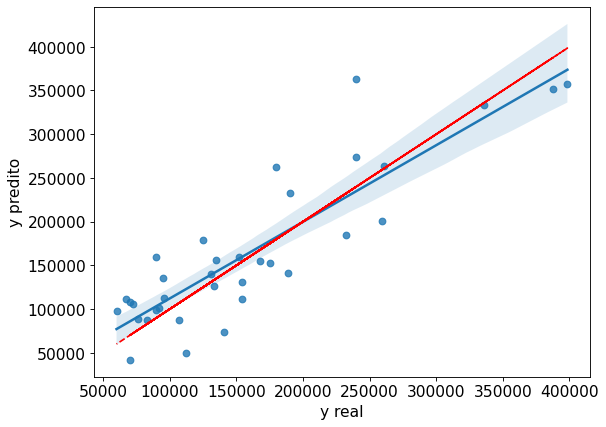

In [62]:
fig = plt.figure(figsize=(8, 6), dpi=80)
plt.rcParams.update({'font.size': 14})
ax = sns.regplot(x = y_test, y = y_pred)
ax.set(xlabel='y real', ylabel='y predito')
ax = plt.plot(y_test, y_test, '--r')

plt.show()

In [63]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [64]:
# Avaliando o modelo
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('MAE',MAE) # Mean Absolute Error (MAE) é a média do valor absoluto dos erros.
print('MSE',MSE) # Erro Quadrático Médio (MSE) é a média dos erros quadráticos
print('r²',r2) # (R-quadrado)

MAE 34422.98857094584
MSE 1844288772.1790097
r² 0.7584591969125003


In [65]:
from sklearn.tree import DecisionTreeRegressor

In [66]:
# Criando o modelo de DecisionTreeRegressor
model_dtr = DecisionTreeRegressor(random_state=7, max_depth=10)
model_dtr.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=10, random_state=7)

In [67]:
y_pred_model_dtr = model_dtr.predict(x_test)

In [68]:
# Avaliando o modelo
MAE = mean_absolute_error(y_test, y_pred_model_dtr)
MSE = mean_squared_error(y_test, y_pred_model_dtr)
r2 = r2_score(y_test, y_pred_model_dtr)
print('MAE',MAE) # Mean Absolute Error (MAE) é a média do valor absoluto dos erros.
print('MSE',MSE) # Erro Quadrático Médio (MSE) é a média dos erros quadráticos
print('r²',r2) # (R-quadrado)

MAE 39338.92244897959
MSE 2532451627.6991253
r² 0.6683326336081382


In [69]:
from sklearn.svm import SVR

In [70]:
# Criando o modelo de SVM
svr = SVR(kernel='linear')

In [71]:
svr.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR(kernel='linear')

In [72]:
y_pred_svr = svr.predict(x_test)

In [73]:
# Avaliando o modelo
MAE = mean_absolute_error(y_test, y_pred_svr)
MSE = mean_squared_error(y_test, y_pred_svr)
r2 = r2_score(y_test, y_pred_svr)
print('MAE',MAE) # Mean Absolute Error (MAE) é a média do valor absoluto dos erros.
print('MSE',MSE) # Erro Quadrático Médio (MSE) é a média dos erros quadráticos
print('r²',r2) # (R-quadrado)

MAE 43153.53918496288
MSE 3123421996.7782364
r² 0.5909350700044546


Com base em alguns dos nossos testes, podemos concluir que o modelo de regressão linear performou melhor do que os demais modelo!